# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("cantidad de nulos\n", users.isna().sum())
print("\nproporcion de nulos\n", users.isna().mean())


cantidad de nulos
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

proporcion de nulos
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("cantidad de nulos\n", usage.isna().sum())
print("\nproporcion de nulos\n", usage.isna().mean())

cantidad de nulos
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

proporcion de nulos
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
 
Para el dataset “*users_latam*”, se encontraron valores nulos en las columnas **city** y **churn_date**, con una proporción respecto al total de registros de **11.7%** y **88.3%**, respectivamente.

Mientras tanto, para el dataset “*usage*”, se encontraron valores nulos en las columnas **date**, **duration** y **length**, con una proporción respecto al total de registros de **0.1%**, **55.2%** y **44.7%**, respectivamente.

- Indica qué harías: ¿imputar, eliminar, ignorar?

Para el dataset “*users_latam*”, en la columna **city**, se pueden imputar los valores nulos con "Unknown" para conservar los demás registros y evitar la pérdida de información relevante de los usuarios.

Para la columna churn_date, debido a que la ausencia de valores puede representar usuarios activos, se puede crear una columna tipo flag que indique si el usuario presenta o no una fecha de cancelación.

Para el dataset “*usage*”, en la columna **date**, los valores nulos pueden ignorarse si la variable temporal no es relevante para el análisis. En caso contrario, se recomienda eliminar dichos registros mediante drop, ya que los nulos representan únicamente el **0.1%** del total y su impacto sobre el análisis sería mínimo.

Para las columnas **duration** y **length**, no se recomienda imputar ni eliminar los valores nulos de forma inmediata, ya que estos podrían representar variables no aplicables según el tipo de registro almacenado.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[["user_id", "age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` registra identificadores numéricos únicos asignados a los usuarios y no presenta anomalías aparentes ni errores de registro.
- La columna `age` registra la edad de los usuarios y contiene valores inválidos, como el valor sentinel **-999**, posiblemente utilizado para representar datos faltantes.

In [13]:
# explorar columnas numéricas de usage
usage[["id", "user_id", "duration", "length"]].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` corresponden a identificadores de registro y de usuario, respectivamente, por lo que no aportan información estadística relevante para el análisis del comportamiento.
- La columna `duration` presenta una media superior a la mediana, lo que sugiere una distribución sesgada hacia la derecha. Además, el valor máximo (120) representa un posible valor atípico, especialmente al compararlo con el tercer cuartil (6.99).
- La columna `length` presenta una distribución relativamente centrada; sin embargo, existen valores considerablemente altos respecto al resto de la distribución, lo que podría indicar errores de registro o patrones de uso inusuales.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].value_counts())
    print("\n------------------------------")


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

------------------------------
Basico     2595
Premium    1405
Name: plan, dtype: int64

------------------------------


- La columna `city` muestra que la mayor concentración de usuarios se encuentra en ciudades como Bogotá, CDMX y Medellín, mientras que ciudades como Cali y MTY presentan una menor cantidad de registros.
Además, se observan registros con valores desconocidos (?), lo que evidencia inconsistencias en la calidad de los datos.

- La columna `plan` evidencia una mayor cantidad de usuarios suscritos al plan Basico en comparación con Premium, lo que podría sugerir una preferencia general por planes de menor costo o con beneficios más ajustados al consumo promedio de los usuarios.


In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` muestra que los registros de tipo text representan la mayor parte del dataset, con 22092 registros, mientras que los registros de tipo call corresponden a 17908. Esto sugiere una mayor frecuencia de uso de mensajes de texto frente a llamadas dentro de los patrones de consumo observados.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
En la columna city se encontraron valores inválidos o inconsistentes, representados mediante símbolos como ? los cuales probablemente corresponden a datos faltantes.

- ¿Qué acción tomarías?
Como acción de limpieza, se recomienda unificar estos valores bajo una única categoría, como "Unknown", para mantener la consistencia del dataset y evitar problemas durante el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False)

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En la columna `reg_date`, se observan registros comprendidos entre los años 2022 y 2024, mostrando una distribución consistente. Sin embargo, también se identificaron registros correspondientes al año 2026, los cuales podrían representar errores de registro o inconsistencias en los datos.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False)

2024.0    39950
NaN          50
Name: date, dtype: int64

La colunma `date`, contiene registros correspondientes al año 2024. No obstante, 50 registros presentaron formatos inválidos o valores faltantes, siendo convertidos a NaT durante la transformación de datos.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años 
imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

En la columna `reg_date` se identificaron registros correspondientes al año 2026, el cual se encuentra fuera del rango temporal esperado para el dataset. Debido a que estos registros representan fechas futuras respecto al periodo analizado, podrían corresponder registros incorrectamente generados.
Como acción recomendada, se sugiere revisar dichos registros para validar su origen. En caso de no poder corregirse mediante información adicional, podrían eliminarse o marcarse como inválidos para evitar distorsiones en el análisis temporal y en la interpretación del comportamiento de los usuarios.

En la columna `date` del dataset **usage**, los registros válidos corresponden únicamente al año 2024, por lo que no se observan años imposibles o fuera de rango. Sin embargo, se detectaron algunos valores inválidos que no pudieron convertirse correctamente al formato fecha y fueron transformados en valores nulos durante el proceso de limpieza.
Debido a que estos registros representan únicamente el **0.1%** del total, se recomienda eliminarlos en caso de que el análisis temporal sea relevante para el estudio.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [30]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [37]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [40]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los valores nulos en las columnas `duration` y `length` dependen directamente de la variable `type`. Los registros de tipo **call** presentan valores nulos en `length`, mientras que los registros **text** presentan valores nulos en `duration`.

Esto indica que los nulos no corresponden a datos faltantes aleatorios, sino a variables no aplicables según el tipo de registro. Por esta razón, se recomienda conservar dichos valores nulos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [48]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes= ("is_text", "sum"),
    cant_llamadas= ("is_call","sum"),
    cant_minutos_llamada= ("duration","sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [53]:
# Renombrar columnas

# observar resultado
usage_agg.tail(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
3996,13997,5,3,11.34
3997,13998,6,6,22.95
3998,13999,3,6,26.46


In [50]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [52]:
# Resumen estadístico de las columnas numéricas
col_numericas= ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[col_numericas].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [59]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize= True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

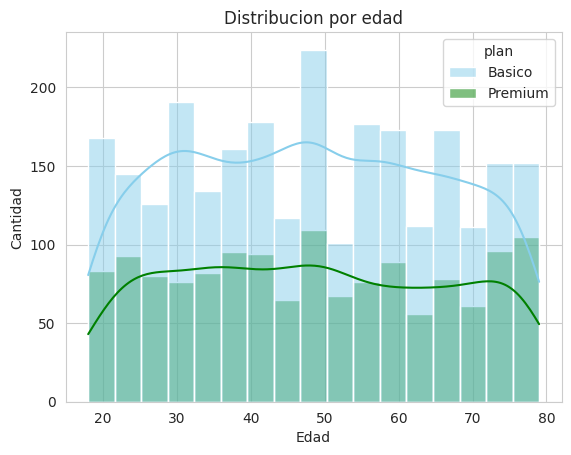

In [106]:
# Histograma para visualizar la edad (age)
sns.set_style("whitegrid")
sns.histplot(data= user_profile, x= 'age', hue= 'plan', palette=['skyblue','green'], kde= True)
plt.title('Distribucion por edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.show()

💡Insights: 
- El plan Basico presenta una mayor cantidad de usuarios en casi todos los rangos de edad respecto a Premium.
- No se observa un patrón claro de preferencia de plan según la edad.
- La distribución de edades es relativamente uniforme, sin un sesgo pronunciado hacia la derecha o izquierda.

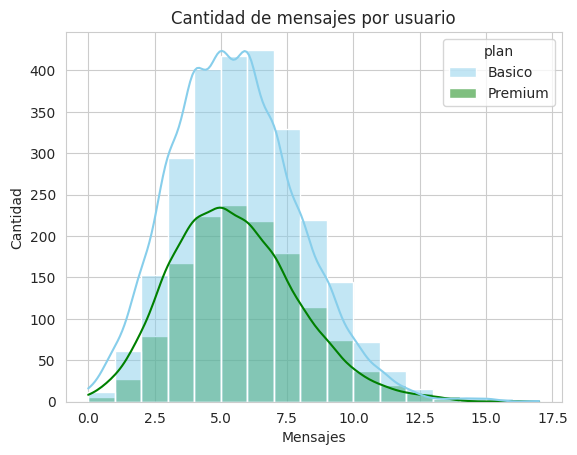

In [105]:
# Histograma para visualizar la cant_mensajes
sns.set_style("whitegrid")
sns.histplot(data= user_profile, x= 'cant_mensajes',bins= 17, hue= 'plan', palette=['skyblue','green'], kde= True)
plt.title('Cantidad de mensajes por usuario')
plt.xlabel('Mensajes')
plt.ylabel('Cantidad')
plt.show()

💡Insights: 
- Los usuarios del plan Basico presentan una mayor cantidad total de mensajes respecto a Premium, aunque ambos planes muestran un comportamiento similar.
- La mayor concentración de usuarios se encuentra entre 4 y 7 mensajes.
- La distribución presenta un sesgo hacia la derecha, debido a algunos usuarios con cantidades de mensajes considerablemente mayores al promedio.

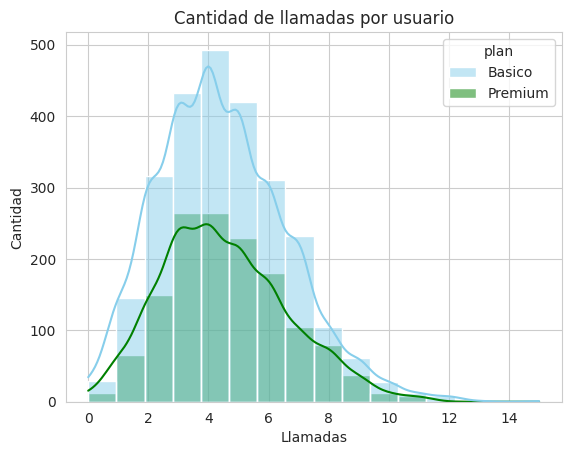

In [114]:
# Histograma para visualizar la cant_llamadas
sns.set_style("whitegrid")
sns.histplot(data= user_profile, x= 'cant_llamadas', bins= 16, hue= 'plan', palette=['skyblue','green'], kde= True)
plt.title('Cantidad de llamadas por usuario')
plt.xlabel('Llamadas')
plt.ylabel('Cantidad')
plt.show()

💡Insights: 
- Los usuarios del plan Basico presentan una mayor cantidad de llamadas en comparación con Premium, aunque ambos planes siguen una distribución similar.
- La mayor concentración de usuarios se encuentra entre 3 y 6 llamadas.
- La distribución presenta un sesgo hacia la derecha, debido a algunos usuarios con cantidades de llamadas superiores al promedio.

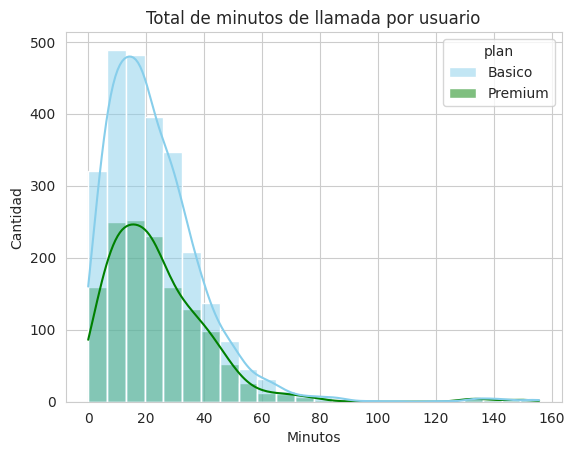

In [109]:
# Histograma para visualizar la cant_minutos_llamada
sns.set_style("whitegrid")
sns.histplot(data= user_profile, x= 'cant_minutos_llamada', bins= 24, hue= 'plan', palette=['skyblue','green'], kde= True)
plt.title('Total de minutos de llamada por usuario')
plt.xlabel('Minutos')
plt.ylabel('Cantidad')
plt.show()

💡Insights: 
- Los usuarios del plan Basico concentran una mayor cantidad total de minutos de llamada respecto a Premium, aunque ambos planes presentan un comportamiento similar.
- La mayor parte de los usuarios acumula entre 5 y 40 minutos de llamadas.
- La distribución presenta un claro sesgo hacia la derecha, debido a la presencia de usuarios con cantidades de minutos considerablemente superiores al promedio

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

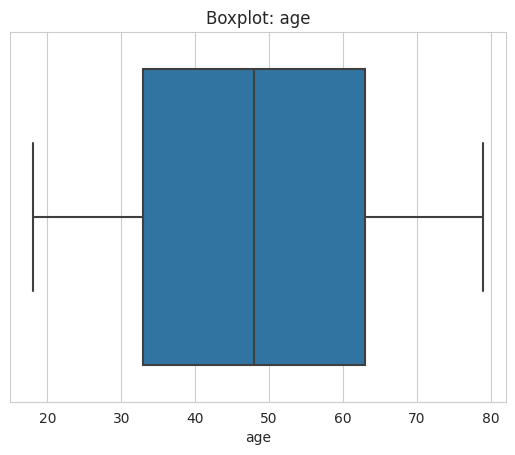

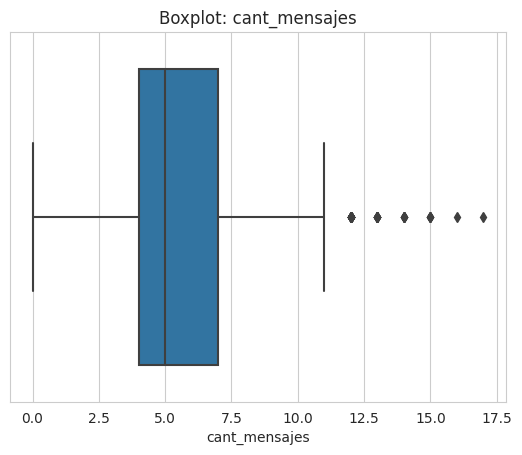

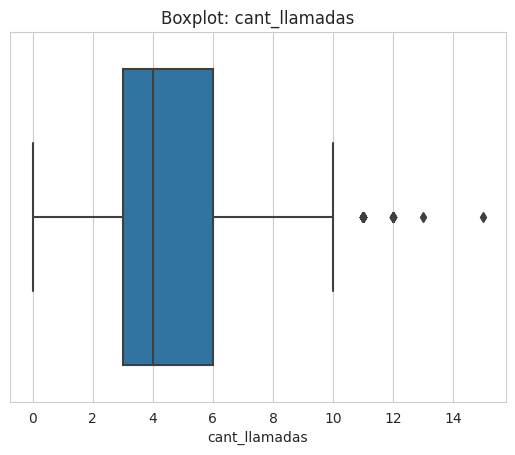

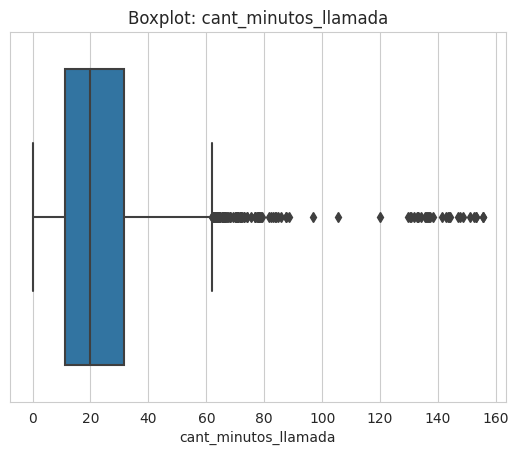

In [116]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Presenta pocos outliers
- cant_llamadas: Presenta pocos outliers
- cant_minutos_llamada: Presenta outliers

In [120]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    quantil_99 = user_profile[col].quantile(0.99)
    print(col, "\nlimite superior", quantil_99, "\n--------------------")



cant_mensajes 
limite superior 12.0 
--------------------
cant_llamadas 
limite superior 10.0 
--------------------
cant_minutos_llamada 
limite superior 82.19759999999998 
--------------------


In [121]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: se recomienda mantener los valores atípicos, ya que pueden representar usuarios con un uso intensivo de mensajería y resultan relevantes para el análisis de patrones de consumo y segmentación de clientes.
- cant_llamadas: se recomienda conservar los outliers, debido a que podrían corresponder a usuarios con una frecuencia de llamadas superior al promedio y no necesariamente a errores de registro.
- cant_minutos_llamada: se recomienda mantener los valores atípicos, ya que el objetivo del análisis incluye identificar comportamientos inusuales y distintos perfiles de consumo. Sin embargo, valores extremadamente altos deberían revisarse para descartar posibles errores de registro.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [122]:
# Crear columna grupo_uso
def clasificar_uso(data):
    if data["cant_llamadas"] < 5 and data["cant_mensajes"] < 5:
        return "Bajo uso"
    elif data["cant_llamadas"] < 10 and data["cant_mensajes"] < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(clasificar_uso, axis=1)

In [123]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [124]:
# Crear columna grupo_edad
def clasificar_edad(data):
    if data["age"] < 30:
        return "Joven"
    elif data["age"] < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(clasificar_edad, axis=1)

In [125]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

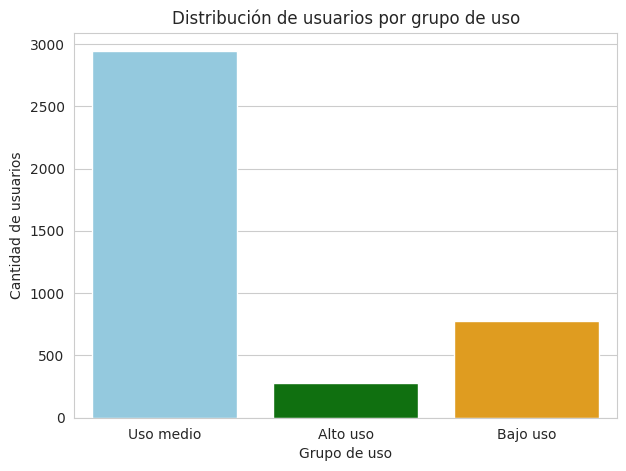

In [126]:
# Visualización de los segmentos por uso
sns.set_style("whitegrid")
plt.figure(figsize=(7,5))

sns.countplot(
    data=user_profile,
    x="grupo_uso",
    palette=["skyblue", "green", "orange"]
)

plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()

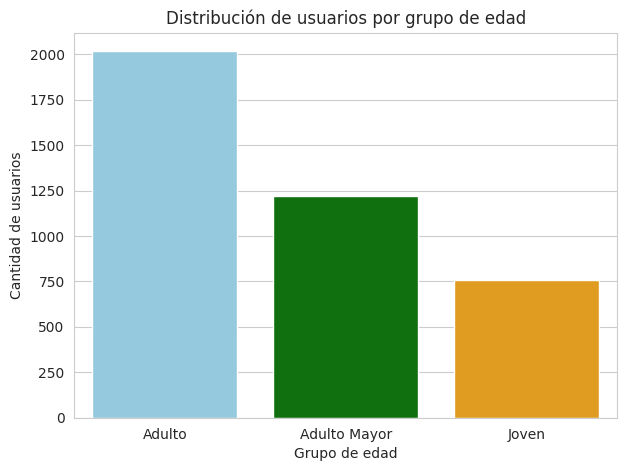

In [127]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7,5))

sns.countplot(
    data=user_profile,
    x="grupo_edad",
    palette=["skyblue", "green", "orange"]
)

plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Durante la exploración y limpieza de datos se identificaron distintos problemas de calidad:

  - La columna `city` presentaba aproximadamente un 11.7% de valores faltantes o inconsistentes, representados mediante símbolos como ? o registros vacíos.
  - La columna `churn_date` contenía alrededor del 88.3% de valores nulos. Sin embargo, estos no fueron considerados errores, ya que representan usuarios activos sin fecha de cancelación.
  - En la columna `age` se detectaron valores inválidos como -999, utilizados posiblemente como sentinels para representar datos faltantes.
  - La columna `date` del dataset usage presentó 50 registros inválidos (0.1% del total) que no pudieron convertirse correctamente al formato fecha.
  - En `reg_date` se identificaron 40 registros correspondientes al año 2026, considerados posibles errores de captura o inconsistencias temporales.
  - Las columnas `duration` y `length` presentaban una alta proporción de valores nulos; sin embargo, se determinó que estos dependían del tipo de registro (call o text), por lo que fueron interpretados como valores no aplicables y no como errores.

⚠️ **Patrones de uso extremo (Outliers)**

Se identificaron valores atípicos en:
  - cant_mensajes
  - cant_llamadas
  - cant_minutos_llamada

especialmente por encima de los percentiles 0.99 definidos para cada variable.
Estos registros no fueron eliminados, ya que podrían representar usuarios con patrones de consumo intensivo y no necesariamente errores de registro.

Para el negocio, estos casos pueden indicar:
clientes de alto valor,
necesidades específicas de consumo,
oportunidades de segmentación avanzada,
o posibles comportamientos inusuales que requieran monitoreo adicional.

🔍 **Segmentos por Edad**

El grupo predominante corresponde a usuarios Adultos.
Los Adultos Mayores representan también una proporción importante del total.
Los usuarios Jovenes constituyen el grupo menos numeroso dentro del dataset.

Además, el plan Basico concentra la mayor cantidad de usuarios en prácticamente todos los segmentos y rangos de edad.

📊 **Segmentos por Nivel de Uso**

Se identificaron principalmente tres segmentos según el nivel de uso:

  - Uso medio: representa la mayor parte de los usuarios, mostrando un comportamiento equilibrado entre llamadas y mensajes.
  - Bajo uso: corresponde a usuarios con menor actividad, posiblemente clientes ocasionales o con necesidades limitadas de comunicación.
  - Alto uso: aunque es el segmento menos numeroso, agrupa usuarios con consumos considerablemente superiores al promedio.

Los usuarios clasificados como Alto uso representan el segmento potencialmente más valioso para ConnectaTel, debido a que generan un mayor consumo de llamadas y mensajes, lo que podría traducirse en mayores ingresos o en oportunidades para ofrecer planes premium y servicios adicionales.

Asimismo, los usuarios Uso medio también resultan estratégicos, ya que constituyen la mayor parte de la base de clientes y representan el segmento con mayor potencial de fidelización y crecimiento comercial.


💡 **Recomendaciones**

 - Diseñar planes orientados específicamente a usuarios de Alto uso, incluyendo mayores beneficios en llamadas y mensajería.
 - Crear estrategias de fidelización para usuarios Uso medio, ya que representan la mayor proporción de clientes activos.
 - Implementar planes más flexibles o económicos para usuarios de Bajo uso, evitando sobrecostos innecesarios y mejorando la satisfacción del cliente.
 - Analizar con mayor profundidad el comportamiento de los usuarios con consumos extremos para identificar oportunidades de monetización o posibles riesgos operativos.
 - Mejorar los procesos de validación y captura de datos para reducir inconsistencias como fechas futuras, sentinels y registros inválidos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`